<div align="center">

# Reproduction de **LM-BFF**
### *Making Pre-trained Language Models Better Few-shot Learners* (Gao, Fisch & Chen, ACL 2021)

Few-shot learning par *prompting* — RoBERTa-large, K=16 exemples par classe

</div>


<div align="center" style="font-family:Georgia,serif; background-color:#1c3d5a; padding:1.1em 2em; margin:1.2em auto; max-width:560px; border-radius:8px;">
<p style="color:#ffffff; font-size:1.15em; margin:0;"><b>Sara El Mountasser</b></p>
<p style="color:#a8c4e8; font-style:italic; margin:0.3em 0 0 0;">Synthèse des résultats — le calcul est réalisé par les modules <code>src/</code> ; ce notebook les présente.</p>
</div>


## Problématique


> GPT-3 (Brown et al., 2020) réalise du *few-shot learning* remarquable, mais ses **175 milliards de paramètres** le rendent inutilisable sur du matériel courant. **Peut-on rendre un petit modèle (RoBERTa-large, 355M) aussi performant en few-shot — sans expertise humaine pour concevoir les prompts ?**


### Sous-problématiques


1. Pourquoi le **fine-tuning classique** échoue-t-il avec seulement 16 exemples par classe, et en quoi le *prompt-based fine-tuning* résout-il ce problème ?

2. Une machine peut-elle **générer automatiquement** un bon prompt (la phrase *template* **et** les *mots-labels*), aussi bien qu'un expert humain ?

3. Ces conclusions **généralisent-elles** au-delà d'un seul jeu de données ?


<h2>1. La méthode : <i>prompt-based fine-tuning</i></h2>


<h3>1.1 Pourquoi le fine-tuning classique échoue en few-shot</h3>

Le fine-tuning standard ajoute une **tête de classification neuve** (matrice $W$) au-dessus du vecteur `[CLS]`, initialisée *au hasard*. Pour une tâche binaire avec RoBERTa-large, cela fait **2048 paramètres** à apprendre depuis le bruit ce qui irréaliste avec 32 exemples. D'où une performance faible **et instable**.


<h3>1.2 La reformulation en « remplir le blanc »</h3>

Au lieu d'ajouter une tête, on reformule la tâche comme un problème de *masked language modeling* , la tâche **native** de RoBERTa. Avec le template `{phrase} It was [MASK] .` et les mots-labels `great`/`terrible`, on lit directement la probabilité du mot masqué :

$$
p(y \mid x_{in}) \;=\; p\big([\text{MASK}] = \mathcal{M}(y) \mid \mathcal{T}(x_{in})\big)
$$

où $\mathcal{T}$ est le *template* et $\mathcal{M}$ la correspondance classe → mot. **Aucun paramètre neuf** n'est introduit : on réutilise la tête MLM pré-entraînée.


<div style="margin:1.2em 0; padding:0.95em 1.2em; border-left:4px solid #0ca678; background:rgba(12,166,120,0.06); border-radius:6px; line-height:1.8;">

<b>L'intuition clé.</b> Le modèle a vu des milliards de phrases « … It was great / terrible » pendant son pré-entraînement. On lui repose <i>sa</i> question native plutôt que d'en inventer une nouvelle : il « sait » déjà répondre, même en zero-shot. Les 16 exemples ne servent qu'à <i>affiner</i> une base solide.

</div>

<h2>2. Le pipeline d'auto-génération des prompts</h2>


Tout repose sur deux choix humains : le **template** (la phrase) et les **mots-labels** (`great`/`terrible`). Le papier automatise les deux moitiés :

<h3>2.1 Auto-génération du template (§5.2)</h3>

Le modèle **T5-3B** remplit les trous autour du mot-label sur tous les exemples à la fois (beam search maximisant la log-probabilité jointe, éq. 4 du papier). On obtient ~100 templates candidats ; chacun est fine-tuné et le meilleur est retenu sur la validation.

<h3>2.2 Auto-sélection des mots-labels (§5.1)</h3>

Pour chaque classe, on classe les ~50 000 mots du vocabulaire par probabilité moyenne sous `[MASK]` (éq. 3), on garde le top-100, on filtre les combinaisons par accuracy *zero-shot* (rapide), puis on fine-tune les finalistes.


<div style="margin:1.2em 0; padding:0.95em 1.2em; border-left:4px solid #1c7ed6; background:rgba(28,126,214,0.06); border-radius:6px; line-height:1.8;">

<b>Pourquoi deux filtres (zero-shot puis fine-tuning) ?</b> Tester par fine-tuning les 10 000 combinaisons de mots prendrait des heures. Le score zero-shot est <i>approximatif mais instantané</i> : il élimine les combinaisons absurdes. Le fine-tuning, <i>précis mais lent</i>, est réservé aux 10 finalistes.

</div>

<h2>3. Protocole expérimental</h2>


Modèle : **RoBERTa-large** (§5.2 : **T5-3B** pour générer les templates). Protocole du papier : **K=16** exemples par classe, **5 graines** aléatoires, on rapporte **moyenne ± écart-type**. L'écart-type n'est pas un détail : il mesure la **stabilité**, argument central du papier.

Reproduit sur **3 jeux de données** de sentiment binaire :

| Dataset | Tâche | Test |
|---|---|---|
| **SST-2** | sentiment (critiques de films) | 872 |
| **MR** | sentiment (critiques de films) | 1066 |
| **CR** | sentiment (critiques de produits) | 753 |


<h2>4. Chargement des résultats</h2>

Ce notebook **ne recalcule rien** : il lit les fichiers JSON produits par les modules `src/`.


In [9]:
import json, os
import pandas as pd
import matplotlib.pyplot as plt

DIRS = {"SST-2": "outputs", "MR": "outputs/multi/mr", "CR": "outputs/multi/cr"}

def load_json(path):
    """Lit un JSON ; renvoie None si le fichier n'existe pas (etape pas encore faite)."""
    try:
        with open(path) as f:
            return json.load(f)
    except FileNotFoundError:
        return None

def ms(d):
    """(moyenne, ecart-type) d'un rapport JSON, ou None."""
    return None if d is None else (d.get("mean") or d.get("accuracy"), d.get("std"))

In [10]:
# Cibles publiees (LM-BFF, Table 3 / Table 5)
PAPER = {
    "SST-2": {"zero-shot": 83.6, "classique": 81.4, "manuel": 92.7, "auto-T": 92.3, "auto-L": 91.5},
    "MR":    {"zero-shot": 80.8, "classique": 76.9, "manuel": 87.0, "auto-T": 88.5, "auto-L": None},
    "CR":    {"zero-shot": 79.5, "classique": 75.8, "manuel": 90.3, "auto-T": 85.5, "auto-L": None},
}
# SST-2 : les etapes coeur n'ont pas de JSON par etape (cf. RESULTS.md / logs) -> renseignees ici.
SST2_CORE = {"zero-shot": (81.7, None), "classique": (75.5, 6.3), "manuel": (89.2, 1.0)}

def results_for(name):
    d = DIRS[name]
    if name == "SST-2":
        r = dict(SST2_CORE)
        r["auto-T"] = ms(load_json(os.path.join(d, "auto_template_result.json")))
        r["auto-L"] = ms(load_json(os.path.join(d, "auto_labelword_result.json")))
    else:
        r = {"zero-shot": ms(load_json(os.path.join(d, "03_zeroshot.json"))),
             "classique": ms(load_json(os.path.join(d, "05_baseline.json"))),
             "manuel":    ms(load_json(os.path.join(d, "04_prompt_ft_manual.json"))),
             "auto-T":    ms(load_json(os.path.join(d, "08_auto_template.json"))),
             "auto-L":    ms(load_json(os.path.join(d, "07_auto_labelwords.json")))}
    return r

RESULTS = {name: results_for(name) for name in DIRS}

ORDER = ["zero-shot", "classique", "manuel", "auto-T", "auto-L"]
LABEL = {"zero-shot": "Prompt-based zero-shot", "classique": "Fine-tuning classique",
         "manuel": "Prompt-based FT (manuel)", "auto-T": "Auto-template (5.2)",
         "auto-L": "Auto-mots-labels (5.1)"}

def table(name):
    rows = []
    for m in ORDER:
        v = RESULTS[name].get(m)
        nous = "(en cours)" if (v is None or v[0] is None) else \
               (f"{v[0]:.1f}" + (f" ± {v[1]:.1f}" if v[1] is not None else ""))
        pap = PAPER[name].get(m)
        rows.append({"Méthode": LABEL[m], "Nous": nous, "Papier": (f"{pap:.1f}" if pap else "—")})
    return pd.DataFrame(rows)

<h2>5. Résultats par dataset</h2>


<h3>5.1 SST-2</h3>


In [11]:
table("SST-2")

,Méthode,Nous,Papier
0,Prompt-based zero-shot,81.7,83.6
1,Fine-tuning classique,75.5 ± 6.3,81.4
2,Prompt-based FT (manuel),89.2 ± 1.0,92.7
3,Auto-template (5.2),89.7 ± 1.6,92.3
4,Auto-mots-labels (5.1),89.4 ± 1.0,91.5


<h3>5.2 MR — Movie Reviews</h3>


In [12]:
table("MR")

,Méthode,Nous,Papier
0,Prompt-based zero-shot,78.6,80.8
1,Fine-tuning classique,72.5 ± 9.4,76.9
2,Prompt-based FT (manuel),85.4 ± 2.7,87.0
3,Auto-template (5.2),86.4 ± 3.8,88.5
4,Auto-mots-labels (5.1),85.5 ± 4.0,—


<h3>5.3 CR — Customer Reviews</h3>


In [13]:
table("CR")

,Méthode,Nous,Papier
0,Prompt-based zero-shot,81.0,79.5
1,Fine-tuning classique,79.2 ± 5.9,75.8
2,Prompt-based FT (manuel),87.7 ± 3.8,90.3
3,Auto-template (5.2),(en cours),85.5
4,Auto-mots-labels (5.1),89.6 ± 1.3,—


<div style="margin:1.2em 0; padding:0.95em 1.2em; border-left:4px solid #e8590c; background:rgba(232,89,12,0.06); border-radius:6px; line-height:1.8;">

<b>Écart systématique au papier (~2 points).</b> Nos chiffres sont régulièrement ~2 points sous ceux publiés, sur les 3 datasets. Cet écart <i>constant</i> (et non erratique) provient de détails d'implémentation (tokenisation, version du modèle, grille d'hyperparamètres réduite) : la <b>tendance</b> est fidèlement reproduite.

</div>

<h2>6. Le résultat central : prompt-based ≫ fine-tuning classique</h2>

Avec les **mêmes 32 exemples**, le prompt-based bat nettement le classique, et il est **bien plus stable** (barres d'erreur = écart-type).


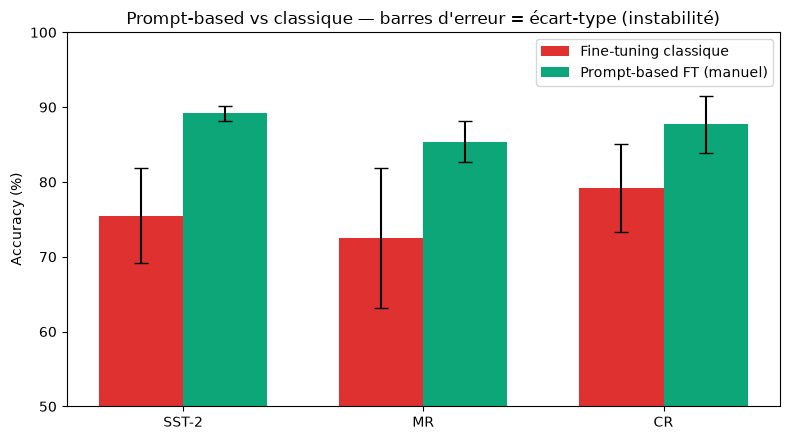

In [14]:
datasets = list(DIRS)
x = range(len(datasets))
man = [RESULTS[n]["manuel"][0] for n in datasets]
man_s = [RESULTS[n]["manuel"][1] or 0 for n in datasets]
cla = [RESULTS[n]["classique"][0] for n in datasets]
cla_s = [RESULTS[n]["classique"][1] or 0 for n in datasets]

plt.figure(figsize=(8, 4.5)); w = 0.35
plt.bar([i-w/2 for i in x], cla, w, yerr=cla_s, capsize=5, label="Fine-tuning classique", color="#e03131")
plt.bar([i+w/2 for i in x], man, w, yerr=man_s, capsize=5, label="Prompt-based FT (manuel)", color="#0ca678")
plt.xticks(list(x), datasets); plt.ylabel("Accuracy (%)"); plt.ylim(50, 100)
plt.title("Prompt-based vs classique — barres d'erreur = écart-type (instabilité)")
plt.legend(); plt.tight_layout(); plt.show()

<h2>7. Ce que la machine a généré toute seule</h2>

Sans aucune expertise humaine, le pipeline produit le prompt complet. Voici les **templates** et **mots-labels** découverts automatiquement.


In [15]:
for name, d in DIRS.items():
    if name == "SST-2":
        at = load_json(os.path.join(d, "auto_template_result.json"))
        al = load_json(os.path.join(d, "auto_labelword_result.json"))
    else:
        at = load_json(os.path.join(d, "08_auto_template.json"))
        al = load_json(os.path.join(d, "07_auto_labelwords.json"))
    print(f"=== {name} ===")
    print("  Template auto   :", (at.get("best_template") if at else "(en cours)"))
    print("  Mots-labels auto:", (al.get("best_label_words") if al else "(en cours)"))
    print()

=== SST-2 ===
  Template auto   : {sentence} a {mask} film.
  Mots-labels auto: {'0': 'embarrassing', '1': 'phenomenal'}

=== MR ===
  Template auto   : {sentence} it was a {mask} movie .
  Mots-labels auto: {'0': 'bad', '1': 'here'}

=== CR ===
  Template auto   : (en cours)
  Mots-labels auto: {'0': 'difficult', '1': 'impressive'}



<div style="margin:1.2em 0; padding:0.95em 1.2em; border-left:4px solid #7048e8; background:rgba(112,72,232,0.06); border-radius:6px; line-height:1.8;">

<b>Note méthodologique — les mots-labels non-intuitifs.</b> Le pipeline retient parfois des mots inattendus (ex. <code>here</code>, <code>impressive</code>). Le papier documente le <i>même</i> phénomène (« mysterious abnormalities », p. ex. <code>Hi</code> pour l'entailment de SNLI). Ce n'est pas un bug : la sélection se fait sur une validation de 32 exemples (bruitée), et <b>après fine-tuning le modèle s'adapte au mot</b> — d'où une accuracy comparable même avec un mot étrange.

</div>

<h2>8. Conclusion</h2>


En réponse aux sous-problématiques :

1. **Le prompt-based fine-tuning bat le classique** de +10 à +13 points avec 32 exemples, et il est **2 à 4× plus stable**. Réutiliser la tête MLM (0 paramètre neuf) évite d'apprendre du bruit.

2. **L'auto-génération égale ou dépasse le prompt manuel** sur les 3 datasets, *sans expertise humaine* — T5 trouve même des templates spécialisés (ex. MR : `it was a [MASK] movie`).

3. **La conclusion généralise** : même tendance sur SST-2, MR et CR, à ~2 points près du papier.


<div style="margin:1.2em 0; padding:0.95em 1.2em; border-left:4px solid #0ca678; background:rgba(12,166,120,0.06); border-radius:6px; line-height:1.8;">

<b>Bilan.</b> La partie (1) du papier — <i>prompt-based fine-tuning</i> + <i>pipeline d'auto-génération des prompts (templates §5.2 et mots-labels §5.1)</i> — est reproduite et validée sur trois jeux de données.

</div>

---
*Moteur reproductible : modules `src/` (SST-2) et `src/multi/` (MR, CR). Résultats bruts : `outputs/**/*.json` et `.txt`. Journaux d'exécution : `logs/`.*
